<h1>Time Series Data Visualization</h1>

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import numpy as np

In [3]:
# figure position

x = [1, 2, 3, 4, 10]
y = [5, 4, 3, 2, 1]

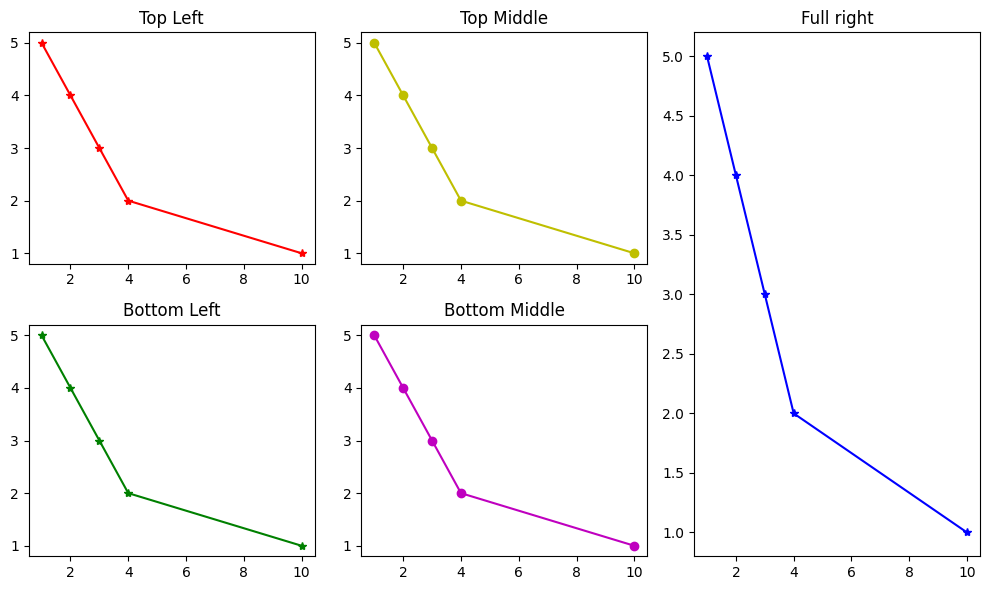

In [5]:
fig = plt.figure(figsize=(10, 6))

gs = gridspec.GridSpec(2, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, y, 'r-*')
ax1.set_title("Top Left")

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x, y, 'g-*')
ax2.set_title("Bottom Left")

ax3 = fig.add_subplot(gs[0, 1])
ax3.plot(x, y, 'y-o')
ax3.set_title("Top Middle")

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(x, y, 'm-o')
ax4.set_title("Bottom Middle")

ax5 = fig.add_subplot(gs[:, 2])
ax5.plot(x, y, 'b-*')
ax5.set_title("Full right")

plt.tight_layout()
plt.show()

In [6]:
df = pd.read_csv("Time Series data.csv")

In [7]:
df.head()

,Avg_Temperature,Ice_Cream_Sales,Power_Cuts
0,25.661274,591.163282,5.0
1,26.560024,657.393558,3.0
2,28.596623,779.978584,4.0
3,28.104512,726.827852,5.0
4,29.889647,775.217459,5.0


In [8]:
df.shape

(120, 3)

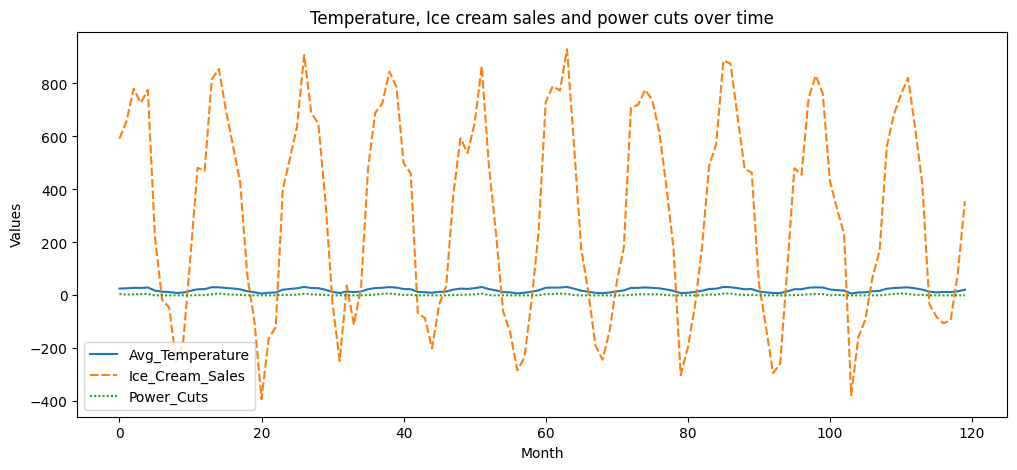

In [9]:
# line plot

plt.figure(figsize=(12, 5))
sns.lineplot(data=df)

plt.title("Temperature, Ice cream sales and power cuts over time")
plt.xlabel("Month")
plt.ylabel("Values")
# plt.legend(["Temperature deg"])

plt.show()

In [10]:
# Moving Average

df['Temp_MA_6'] = df['Avg_Temperature'].rolling(window=6).mean()

df['Ice_cream_MA_6'] = df['Ice_Cream_Sales'].rolling(window=6).mean()

In [11]:
df.head()

,Avg_Temperature,Ice_Cream_Sales,Power_Cuts,Temp_MA_6,Ice_cream_MA_6
0,25.661274,591.163282,5.0,NaN,NaN
1,26.560024,657.393558,3.0,NaN,NaN
2,28.596623,779.978584,4.0,NaN,NaN
3,28.104512,726.827852,5.0,NaN,NaN
4,29.889647,775.217459,5.0,NaN,NaN


In [12]:
df.head(10)

,Avg_Temperature,Ice_Cream_Sales,Power_Cuts,Temp_MA_6,Ice_cream_MA_6
0,25.661274,591.163282,5.0,NaN,NaN
1,26.560024,657.393558,3.0,NaN,NaN
2,28.596623,779.978584,4.0,NaN,NaN
3,28.104512,726.827852,5.0,NaN,NaN
4,29.889647,775.217459,5.0,NaN,NaN
5,18.074189,220.867731,0.0,26.147711,625.241411
6,13.913798,-16.165218,0.0,24.189799,524.019994
7,12.661206,-45.941386,0.0,21.873329,406.797504
8,9.110366,-251.292061,0.0,18.625619,234.919063
9,10.641652,-170.066611,0.0,15.715143,85.436652


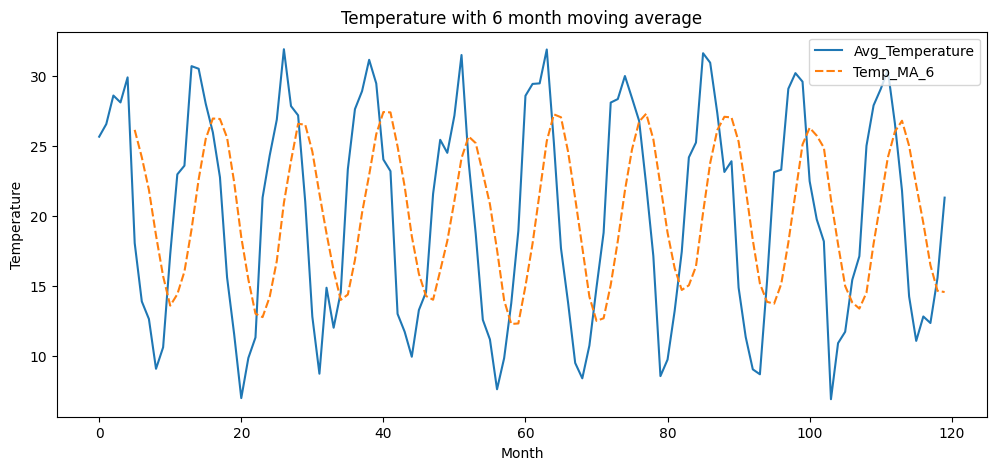

In [15]:
# Moving Average Plot

plt.figure(figsize=(12, 5))
sns.lineplot(data=df[['Avg_Temperature', 'Temp_MA_6']])
plt.title("Temperature with 6 month moving average")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

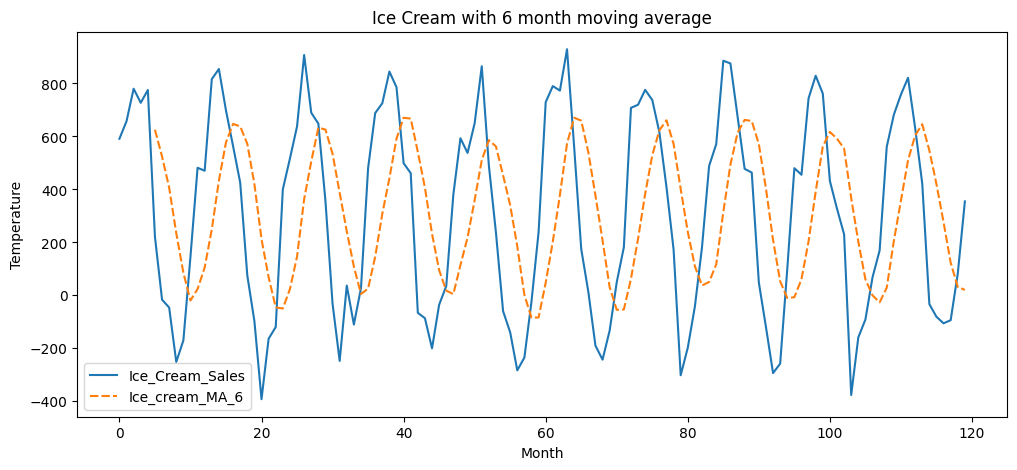

In [17]:
# Moving Average Plot

plt.figure(figsize=(12, 5))
sns.lineplot(data=df[['Ice_Cream_Sales', 'Ice_cream_MA_6']])
plt.title("Ice Cream with 6 month moving average")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

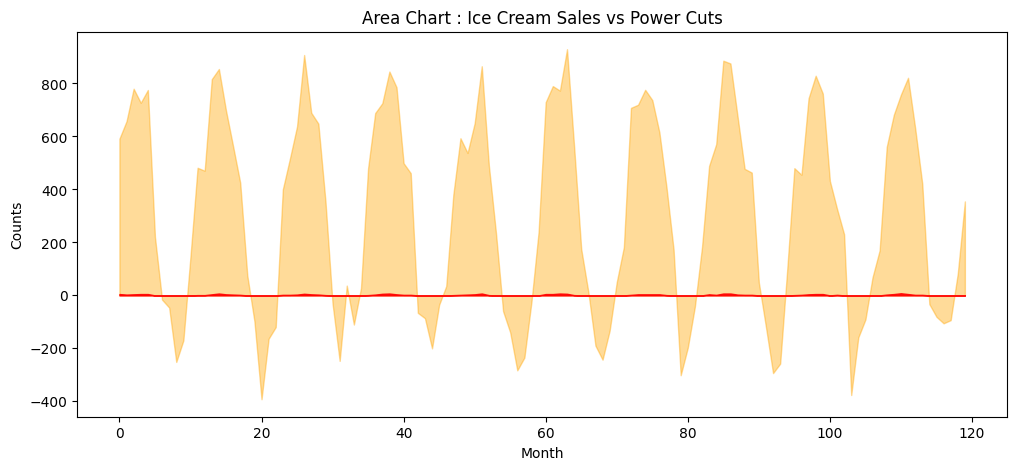

In [20]:
# Area Chart

plt.figure(figsize=(12, 5))

plt.fill_between(df.index, df['Ice_Cream_Sales'], alpha=0.4, label='Ice Cream Sales', color='orange')
plt.fill_between(df.index, df['Power_Cuts'], alpha=0.9, label='Power Cuts', color='red')
plt.title("Area Chart : Ice Cream Sales vs Power Cuts")
plt.xlabel("Month")
plt.ylabel("Counts")
plt.show()

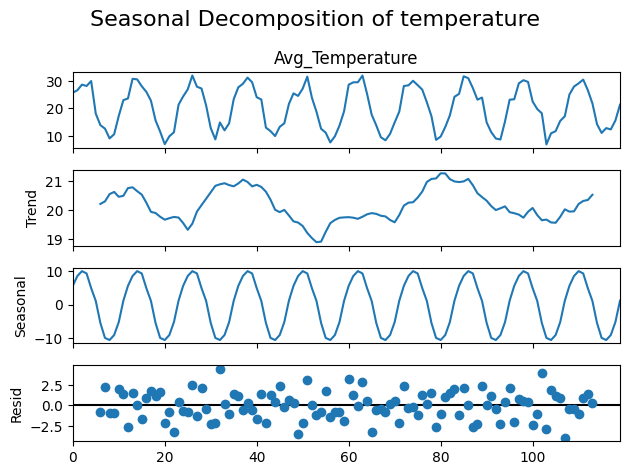

In [23]:
# seasonal_decompose

result = seasonal_decompose(df['Avg_Temperature'], model="additive", period=12)
result.plot()
plt.suptitle("Seasonal Decomposition of temperature", fontsize=16)
plt.tight_layout()
plt.show()